# Simple RAG Agent using LangChain (create_agent) & FAISS

This notebook demonstrates how to build a simple **Retrieval-Augmented Generation (RAG)** Agent using **pure LangChain (`create_agent`)** and a **FAISS vector database** in-memory.

### System Flow:
1. **Knowledge Base**: We define a set of local document texts.
2. **Vector Store**: We embed these texts using `GoogleGenerativeAIEmbeddings` and store them in an in-memory `FAISS` vector database.
3. **Retriever Tool**: We expose the vector database retriever as a LangChain `@tool` so the agent can query it.
4. **RAG Agent**: We use `create_agent` to initialize an agent that queries the retriever tool to answer questions, cite sources, and respond to the user.
5. **Real-time Streaming**: We stream the agent's step-by-step tool calls and model tokens in real-time.

## 1. Setup & Environment Variables
Set up the API keys and initialize the virtual environment variables.

In [1]:
import os
from getpass import getpass
from dotenv import load_dotenv

# Load keys from root directory .env if present
load_dotenv(dotenv_path="../.env")

if "GEMINI_API_KEY" not in os.environ:
    if "GOOGLE_API_KEY" in os.environ:
        os.environ["GEMINI_API_KEY"] = os.environ["GOOGLE_API_KEY"]
    else:
        os.environ["GEMINI_API_KEY"] = getpass("Enter your GEMINI API Key: ")

## 2. Initialize Embeddings & FAISS Vector Database
We'll define a set of basic documents containing facts and information, initialize the `GoogleGenerativeAIEmbeddings` class, and load everything into an in-memory `FAISS` database.

In [2]:
from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

# Workaround for batch embedding bug in langchain-google-genai v4.2.2
class PatchedGoogleGenerativeAIEmbeddings(GoogleGenerativeAIEmbeddings):
    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return [self.embed_query(t) for t in texts]

# 1. Define a basic mock knowledge base
knowledge_base = [
    Document(
        page_content=(
            "Google Gemini is a family of highly capable multimodal AI models developed by Google. "
            "The latest generation includes gemini-3.1-flash, gemini-3.1-flash-lite, and gemini-3.1-pro. "
            "These models support text, image, audio, video, and code processing with a 1-million token context window."
        ),
        metadata={"source": "Gemini Fact Sheet"}
    ),
    Document(
        page_content=(
            "FAISS (Facebook AI Similarity Search) is a library for efficient similarity search and clustering "
            "of dense vectors. It contains algorithms that search in sets of vectors of any size, up to ones that "
            "possibly do not fit in RAM. It is widely used in vector databases and semantic search systems."
        ),
        metadata={"source": "FAISS Documentation"}
    ),
    Document(
        page_content=(
            "LangChain is an open-source framework designed to simplify the creation of applications "
            "using large language models (LLMs). It provides components like prompt templates, models, "
            "output parsers, vectorstores, and agents that can be composed to build complex applications."
        ),
        metadata={"source": "LangChain Overview"}
    ),
    Document(
        page_content=(
            "Retrieval-Augmented Generation (RAG) is a technique that enhances LLMs by retrieving relevant "
            "information from an external data source (like a vector database) and injecting it into the prompt. "
            "This helps reduce model hallucinations, provides up-to-date information, and leverages proprietary data."
        ),
        metadata={"source": "RAG Architecture Guide"}
    )
]

# 2. Initialize Google Generative AI Embeddings
embeddings = PatchedGoogleGenerativeAIEmbeddings(model="models/gemini-embedding-2")

# 3. Create FAISS Vector Database in-memory
vector_store = FAISS.from_documents(knowledge_base, embeddings)
print("FAISS Vector Database successfully initialized with mock documents!")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


FAISS Vector Database successfully initialized with mock documents!


## 3. Define Retriever Tool
Now, we wrap the FAISS retriever in a LangChain `@tool` so that our agent can access it during execution.

In [3]:
from langchain.tools import tool

@tool
def query_knowledge_base(query: str) -> str:
    """Queries the vector database knowledge base for information matching the search query and returns relevant documents."""
    try:
        # Perform a similarity search in FAISS
        results = vector_store.similarity_search(query, k=2)
        if not results:
            return f"No matching information found in the knowledge base for: '{query}'"
        
        output_str = f"Matching Documents found for '{query}':\n\n"
        for i, doc in enumerate(results, 1):
            output_str += f"Document {i}:\n"
            output_str += f"Content: {doc.page_content}\n"
            output_str += f"Source Metadata: {doc.metadata.get('source', 'Unknown')}\n\n"
        return output_str
    except Exception as e:
        return f"Error querying knowledge base: {str(e)}"

## 4. Instantiate RAG Agent
We'll use LangChain's `create_agent` to construct our RAG agent, equipping it with the retriever tool.

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


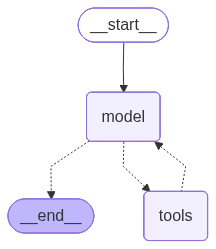

In [4]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the chat model
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# Define System Prompt
rag_system_prompt = (
    "You are a specialized RAG Assistant. Your goal is to answer user queries using the query_knowledge_base tool. "
    "Whenever the user asks a question, always query the knowledge base first to retrieve facts. "
    "Answer based strictly on the retrieved contents. Do not make up facts. "
    "Always cite the source of your information in your final answer (e.g. '[Source: Gemini Fact Sheet]')."
)

# Create the RAG Agent
rag_agent = create_agent(
    model=llm,
    tools=[query_knowledge_base],
    system_prompt=rag_system_prompt
)

rag_agent
#print("RAG Agent successfully instantiated!")

## 5. Execution Run
Let's test the RAG Agent with a query that requires retrieving information from our mock documents.

In [5]:
query = "Can you explain what Google Gemini is and list some of the latest models?"
print(f"User Query: {query}\n")

response = rag_agent.invoke({"messages": [{"role": "user", "content": query}]})
print("=== RAG AGENT ANSWER ===\n")
print(response["messages"][-1].content)

User Query: Can you explain what Google Gemini is and list some of the latest models?

=== RAG AGENT ANSWER ===

[{'type': 'text', 'text': 'Google Gemini is a family of highly capable multimodal AI models developed by Google. These models are designed to process and understand various types of information, including text, images, audio, video, and code, and they feature a 1-million token context window [Source: Gemini Fact Sheet].\n\nThe latest generation of Gemini models includes:\n*   **gemini-3.1-flash**\n*   **gemini-3.1-flash-lite**\n*   **gemini-3.1-pro**\n\n[Source: Gemini Fact Sheet]', 'extras': {'signature': 'EjQKMgEMOdbHQKaOrLAsWhTrzSJelHMVqc00KUOKYiVwWfNa0ULD7FkdOqB1ZhAJ+/0mlx1N'}}]


In [6]:
print(response["messages"][-1].content[0]['text'])

Google Gemini is a family of highly capable multimodal AI models developed by Google. These models are designed to process and understand various types of information, including text, images, audio, video, and code, and they feature a 1-million token context window [Source: Gemini Fact Sheet].

The latest generation of Gemini models includes:
*   **gemini-3.1-flash**
*   **gemini-3.1-flash-lite**
*   **gemini-3.1-pro**

[Source: Gemini Fact Sheet]


## 6. Real-Time Streaming with astream_events
This cell implements true real-time event streaming for the RAG Agent, printing retriever tool execution and the model's generated output tokens as they arrive.

In [7]:
import asyncio
import nest_asyncio
from rich.console import Console
from rich.panel import Panel
from langchain_core.messages import HumanMessage

nest_asyncio.apply()
console = Console()

async def stream_rag_agent(agent, user_query: str):
    console.print("\n" + "="*80, style="bold cyan")
    console.print("🔍 RAG AGENT (REAL-TIME STREAMING)", style="bold magenta")
    console.print("="*80, style="bold cyan")
    console.print(f"\n[bold yellow]User Query:[/bold yellow] {user_query}")
    console.print("\n[bold magenta]🤖 Starting Execution...[/bold magenta]")
    console.print("[bold cyan]" + "─" * 80 + "[/bold cyan]\n")
    
    active_tool = False
    
    try:
        async for event in agent.astream_events(
            {"messages": [HumanMessage(content=user_query)]},
            version="v2"
        ):
            event_type = event.get("event")
            name = event.get("name")
            
            if event_type == "on_tool_start":
                active_tool = True
                inputs = event.get("data", {}).get("input")
                console.print(f"\n\n[bold green]🔧 [Tool Start] {name}[/bold green]")
                console.print(f"  [dim]Input: {inputs}[/dim]\n")
                
            elif event_type == "on_tool_end":
                active_tool = False
                output = event.get("data", {}).get("output")
                console.print(f"\n[bold green]✓ [Tool End] {name} Result:[/bold green]")
                console.print(Panel(str(output).strip(), style="green", expand=False))
                console.print()
                
            elif event_type == "on_chat_model_stream":
                chunk = event.get("data", {}).get("chunk")
                content = chunk.content if hasattr(chunk, 'content') else str(chunk)
                
                if not active_tool:
                    # Stream the agent's thoughts and final answer
                    console.print(content, style="cyan", end="")
        console.print("\n")
    except Exception as e:
        console.print(f"\n[bold red]❌ ERROR:[/bold red] {str(e)}")



In [8]:
stream_query = "What is FAISS and what is it used for?"
asyncio.run(stream_rag_agent(rag_agent, stream_query))

================================================================================

🔍 RAG AGENT (REAL-TIME STREAMING)

================================================================================

User Query: What is FAISS and what is it used for?

🤖 Starting Execution...

...

[
    {
        'type': 'text',
        'text': '\n\nIt is primarily used in:\n*   **Vector Databases:** Serving as a core component for managing 
and querying high',
        'index': 0
    }
]

[
    {
        'type': 'text',
        'text': '-dimensional data.\n*   **Semantic Search Systems:** Enabling fast and accurate retrieval of 
information based on vector similarity.\n\n',
        'index': 0
    }
]

[{'type': 'text', 'text': '[Source: FAISS Documentation]', 'index': 0}]

[
    {
        'type': 'text',
        'text': '',
        'extras': {'signature': 'EjQKMgEMOdbHufKAgfC1uBmJIBNq0LKarq8ZpBoSXyi/a7e9KJis3d+0qcj/pD6+jdfWILYx'},
        'index': 0
    }
]

[]